# Credit Risk Analysis Using Quantum Computers

### Sources
Underlying papers:
- <a href="https://www.nature.com/articles/s41534-019-0130-6">Quantum Risk Analysis. Stefan Woerner, Daniel J. Egger.</a> [Woerner2019]
- <a href="https://arxiv.org/abs/1907.03044">Credit Risk Analysis using Quantum Computers. Egger et al. (2019)</a> [Egger2019]
- <a href="https://qiskit.org/documentation/tutorials/finance/09_credit_risk_analysis.html">Credit Risk Analysis . IBM's Qiskit</a> [Qiskit2020]
- <a href="https://qiskit.org/documentation/tutorials/circuits/3_summary_of_quantum_operations.html">Summary of Quantum Operations . IBM's Qiskit</a> [QiskitSummary2020]
- <a href="https://github.com/qiskit-community/qiskit-algorithms">Qiskit Algorithms</a>
- https://link.springer.com/content/pdf/10.1007/s11128-019-2565-2.pdf

### Problem Description
Assume a portfolio of multiple obligors with their one year probabilities of default $p_{k}$ and respective loss given default (LGD). And we want to calculate the Loss of that portfolio. When losses are independent the portfolio loss is simply $L = \sum_{k=0}^{K} X_{k} * LGD_{k}$, where $X_k \in \{0,1\}$ is a Bernoulli random variable representing the survival or the default of the respective obligor. Where 0 stands for survival and 1 for default. This is also called the Indicator Function. The probability of obligor $k$ defaulting within a one year time horizon and $X_k$ to become $1$ is denoted with $p_k$. The probability of obligor k surviving therefore is $(1-p_k)$.

In an environment where the obligor defaults $X_k$ are no no longer independent we can define a Gaussian Conditional Independence Model ([Li1999], [Vasicek2002] where each obligor's default probability is dependent on a common risk factor $Z$ with its realization $z$, representing the systematic risk. $Z$ has usually a Standard Normal Distribution. The unconditional default probability is:

$$p_k(z) = F\left( \frac{F^{-1}(p_k^0) - \sqrt{\rho_k}z}{\sqrt{1 - \rho_k}} \right) $$

where 

- $\rho_k$ is the correlation of obligor k to the latent random variable $Z$ following a Standard Normal Distribution
- $F$ is the cumulative distribution function of the random variable Z representing the common risk factor
- and $z$ is discretized and truncated between $z_{min}$ and $z_{max}$ and take $2^{n_z}$ values
- $p_k^0$ denotes the unconditional default probability of the obligor k for $z=0$



### Setup in Qiskit

In [1]:
# Import necessary libraries
import numpy as np
from qiskit import QuantumCircuit, transpile, assemble, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm, linregress
from qiskit.visualization import plot_bloch_multivector 
import time
from numpy import pi
from qiskit.visualization import plot_histogram
from qiskit_aer.primitives import Sampler
%matplotlib inline  
# need to conda install -c conda-forge

from qiskit.circuit.library import WeightedAdder
from qiskit.circuit.library import IntegerComparator
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem

from qiskit.circuit.library import QFT 
from qiskit_finance.circuit.library import GaussianConditionalIndependenceModel as GCI
from qiskit.converters import circuit_to_gate
from qiskit.circuit.library import MCMT as mcmt
from qiskit.circuit.library import MCMTVChain as MCMTVChain
from qiskit.circuit.library import ZGate as ZGate
from qiskit.circuit.library import MCXGate

from qiskit.circuit.library import MCXGrayCode, MCXRecursive, MCXVChain
from qiskit.circuit.library import MCXRecursive

from scipy.stats import norm
from scipy.optimize import curve_fit
from math import asin, sqrt, sin
from scipy.stats import beta
from scipy.stats import binom

In [2]:
# Create the MCX (multi-controlled X) gate
mcx = MCXGate(num_ctrl_qubits=3)

In [3]:
# Parameter setting
p_k = [0.15, 0.25]
rhos = [0.1, 0.05]
lgd = [1, 2]
n_z = 2 # number of qubits representing the Standard Normal Distribution
z_max = 2
z_values = np.linspace(-z_max, z_max, 2**n_z)
num_qubits = 4 # Total number of qubits: 2 for the distribution and 2 for the obligors in the portfolio
K = len(p_k)

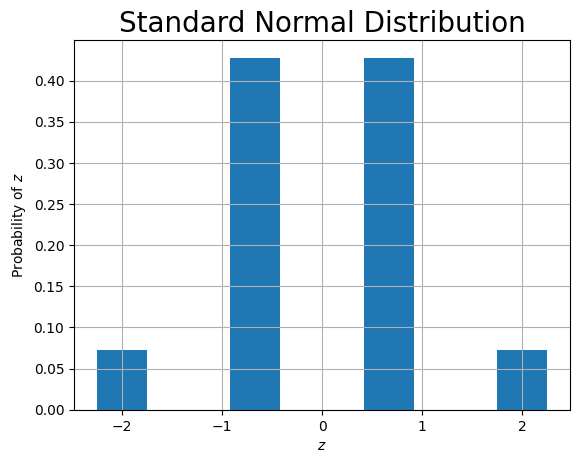

In [4]:
# Standard Normal Distribution 
# with parameters
mu = 0
sigma = 1

normal_x = z_values
normal_y = norm.pdf(z_values) / sum(norm.pdf(z_values))

plt.bar(normal_x, normal_y, width=0.5)
plt.grid()
plt.title("Standard Normal Distribution", size=20)
plt.xlabel('$z$')
plt.ylabel('Probability of $z$')
plt.show()

### Initializing the Quantum Circuit to produce values from the Standard Normal Distribution
Using multiplexing which is directly available through Qiskit

In [5]:
q = QuantumRegister(n_z, name='q')
qc = QuantumCircuit(q)

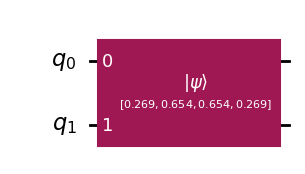

In [6]:
desired_vector = np.sqrt(normal_y)
qc.initialize(desired_vector, [q[0],q[1]])
qc.draw('mpl')

### Show that the quantum circuit produces values of the Standard Normal Distribution when measured

00 :  0.07228887523293863
01 :  0.42771112476706136
10 :  0.42771112476706136
11 :  0.07228887523293863


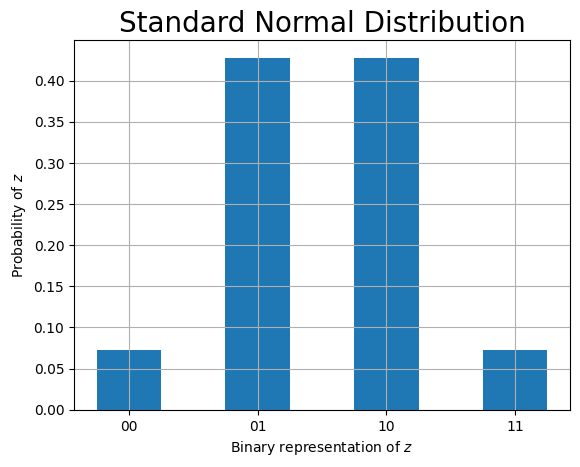

In [7]:
backend = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
statevector = result.get_statevector()
array = np.asarray(statevector)

values = []
probabilities = []
for i, a in enumerate(array):
    b = ('{0:0%sb}' % n_z).format(i)
    prob = np.abs(a)**2
    print(b, ": ", prob)
    values += [b]
    probabilities += [prob]
    
plt.bar(values, probabilities, width=0.5)
plt.grid()
plt.title("Standard Normal Distribution", size=20)
plt.xlabel('Binary representation of $z$')
plt.ylabel('Probability of $z$')
plt.show()

### Wave Function Representation of the default event of a single obligor

The wave function of a single obligor is denoted as

$$ |\Psi\rangle = \left( \sqrt{1 - p_k(z_i)}|0\rangle + \sqrt{p_k(z_i)}|1\rangle\right),$$

with the probability $|\sqrt{p_k(z)}|^2$ for default $|1\rangle$ and $|\sqrt{1-p_k(z)}|^2$ for survival $|0\rangle$.

In order to implement this in a quantum circuit we use the convenient and standard representation of the quantum state of a single qubit

$$\left|\psi\right\rangle = \cos(\theta/2)\left|0\right\rangle + \sin(\theta/2)\left|1\right\rangle$$

and its unitary

$$
U = \begin{pmatrix}
\cos(\theta/2) & \sin(\theta/2) \\
\sin(\theta/2) & \cos(\theta/2) 
\end{pmatrix}.
$$

and set 

- $\cos(\theta/2) = \sqrt{1-p_k(z)}$ and
- $\sin(\theta/2) = \sqrt{p_k(z)}$

to transform the general form into the desired form we derive the rotation angle in the Bloch-Sphere

$\theta_p^k(z_i) = 2 \arcsin(\sqrt{p_k(z)})$

We use a first order approximation to implement this rotation of $z$ to control $X_k$.

$\theta_p^k(z_i) = 2 \arcsin(\sqrt{p_k(z)}) \approx a_k * i + b_k$ for $i \in \{0,...,2^{n_z-1}\}$

where $a_k$ is the slope and $b_k$ the offset with the ordinate of $\theta_p^k(z_i)$.

The full wave function of the uncertainty model looks as follows. It can be achieved by creating a quantum state in a register of $n_z$ qubits that represents $Z$ following a standard normal distribution. This state is then used to control single qubit Y-rotations on a second qubit register of $K$ qubits, where a $|1\rangle$ state of qubit $k$ represents the default event of asset $k$. The resulting quantum state can be written as

$$ |\Psi\rangle = \sum_{i=0}^{2^{n_z}-1} \sqrt{p_z^i} |z_i \rangle \bigotimes_{k=1}^K 
\left( \sqrt{1 - p_k(z_i)}|0\rangle + \sqrt{p_k(z_i)}|1\rangle\right),$$

where we denote by $z_i$ the $i$-th value of the discretized and truncated $Z$ [Egger2019].

### Linear approximation of the rotation $\theta_p^k(z_i)$ (Linear regression)

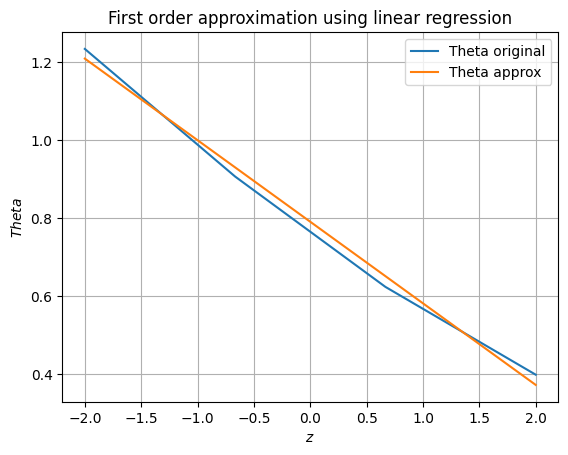

In [8]:
# Linear approxiation of the rotation Theta
p_k_z_1 = norm.cdf((norm.ppf(p_k[0]) - np.sqrt(rhos[0]) * z_values) / np.sqrt(1-rhos[0]))
p_k_z_2 = norm.cdf((norm.ppf(p_k[1]) - np.sqrt(rhos[1]) * z_values) / np.sqrt(1-rhos[1]))
theta_p_k_z_1 = 2*np.arcsin(np.sqrt(p_k_z_1))
theta_p_k_z_2 = 2*np.arcsin(np.sqrt(p_k_z_2))

plt.plot(z_values, theta_p_k_z_1, label='Theta original')

# Linear Regression 
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(z_values, theta_p_k_z_1)
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(z_values, theta_p_k_z_2)
a_k = [slope1, slope2]
b_k = [intercept1, intercept2]

#check by plotting the function
func = []
for i in z_values:
    func.append(intercept1 + i * slope1)
plt.plot(z_values, np.array(func), label='Theta approx')
plt.title("First order approximation using linear regression", size=12)
plt.grid()
plt.xlabel('$z$')
plt.ylabel('$Theta$')
plt.legend(loc="upper right")
plt.show()

# Linear Regression over i and z for the affine mapping of i to z_i
slope_z, intercept_z, r_value_z, p_valuez, std_err_z = linregress(np.arange(0, (2**n_z)), z_values)

# Combined slope and intercept
a_k = [slope_z*slope1, slope_z*slope2]
b_k = [intercept_z*slope1 + intercept1, intercept_z*slope2 + intercept2]

### Analytical solution to derive the slope and offset of $\theta_p^k(z_i)$ (Tangent)

The rotation angle $\theta_p^k(z_i)$ is symmetric around $z=0$ due to symmetrie of the standard normal distribution. We can therefore calculate $\theta_p^k(z=0)$ to derive the offset with the ordinate. And take the derivative of $\theta_p^k(z)$ to determine the slope of the function at $z=0$.

We have the conditional default probability $$p_k(z) =  F\left( \frac{F^{-1}(p_k^0) - \sqrt{\rho_k}z}{\sqrt{1 - \rho_k}} \right)$$

the rotation angle

$$\theta_p^k(z_i) = 2 \arcsin \left(\sqrt{p_k(z)} \right)$$

and let $$p_k(0) = F(\Psi) = F\left( \frac{F^{-1}(p_k^0)}{\sqrt{1 - \rho_k}} \right)$$

where $$\Psi = \frac{F^{-1}(p_k^0)}{\sqrt{1 - \rho_k}}$$

Offset:

$$\theta_p^k(0) = 2 \arcsin(\sqrt{p_k(0)}) = 2 \arcsin \left(\sqrt{F(\Psi) }\right)$$

Slope:

$$\frac{\partial \theta_p^k(z)}{\partial z} = 2 \frac{1}{\sqrt{1-p_k(z)}} \frac{1}{2 \sqrt{p_k(z)}}f\left( \frac{F^{-1}(p_k^0) - \sqrt{\rho_k}z}{\sqrt{1 - \rho_k}} \right) \frac{-\sqrt{\rho}}{\sqrt{1-\rho}}$$

Setting $z=0$ we get

$$ = \frac{1}{\sqrt{1-p_k(0)}} \frac{1}{\sqrt{p_k(0)}}f\left( \frac{F^{-1}(p_k^0) - \sqrt{\rho_k}z}{\sqrt{1 - \rho_k}} \right) \frac{-\sqrt{\rho}}{\sqrt{1-\rho}} = \frac{1}{\sqrt{1-F(\Psi)}} \frac{1}{\sqrt{F(\Psi)}}f(\Psi) \frac{-\sqrt{\rho}}{\sqrt{1-\rho}}$$

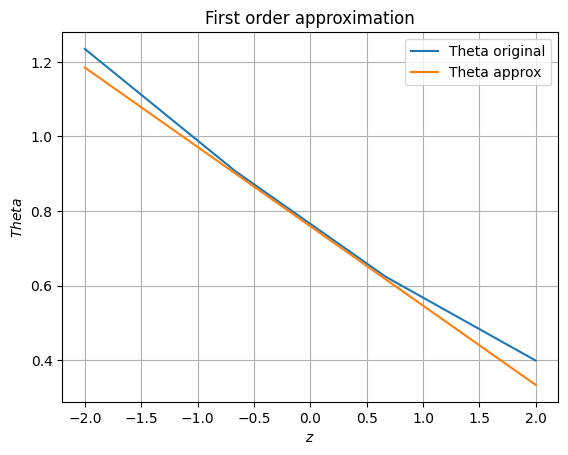

In [9]:
p_k_z_1 = norm.cdf((norm.ppf(p_k[0]) - np.sqrt(rhos[0]) * z_values) / np.sqrt(1-rhos[0]))
p_k_z_2 = norm.cdf((norm.ppf(p_k[1]) - np.sqrt(rhos[1]) * z_values) / np.sqrt(1-rhos[1]))
theta_p_k_z_1 = 2*np.arcsin(np.sqrt(p_k_z_1))
theta_p_k_z_2 = 2*np.arcsin(np.sqrt(p_k_z_2))

plt.plot(z_values, theta_p_k_z_1, label='Theta original')

psi1 = norm.ppf(p_k[0]) / np.sqrt(1-rhos[0])
psi2 = norm.ppf(p_k[1]) / np.sqrt(1-rhos[1])

offset1 = 2*np.arcsin(np.sqrt(norm.cdf(psi1)))
offset2 = 2*np.arcsin(np.sqrt(norm.cdf(psi2)))

slope1 = 1 / np.sqrt(1-norm.cdf(psi1)) / np.sqrt(norm.cdf(psi1)) * norm.pdf(psi1) * - np.sqrt(rhos[0]) / np.sqrt(1-rhos[0])
slope2 = 1 / np.sqrt(1-norm.cdf(psi2)) / np.sqrt(norm.cdf(psi2)) * norm.pdf(psi2) * - np.sqrt(rhos[1]) / np.sqrt(1-rhos[1])

a_k = [slope1, slope2]
b_k = [offset1, offset2]

# Plotting the function
func = []
for i in z_values:
    func.append(offset1 + i * slope1)
plt.plot(z_values, np.array(func), label='Theta approx')
plt.title("First order approximation", size=12)
plt.grid()
plt.xlabel('$z$')
plt.ylabel('$Theta$')
plt.legend(loc="upper right")
plt.show()

#### Including affine mapping 

$\theta_p^k(z_i) = 2 \arcsin \left(\sqrt{p_k(z)} \right) \approx a_k z_i + b_k$ and $z_i = a_z  i + b_z$ for $i \in \{0,...,2^{n_z-1}\}$

where $z$ is discretized and truncated between $z_{min}$ and $z_{max}$ and take $2^{n_z}$ values. Therefore $a_z =  \frac{|\left(z_{max} - z_{min} \right)|}{2^{n_z}-1}$ and $b_z = z_{min}$.

Combined offset and slope: $a_k  (a_z  i + b_z) + b_k = a_k a_z i + a_k b_z + b_k$

#### Offset including affine mapping

$$a_k b_z + b_k = a_k z_{min} + b_k = -a_k z_{max} + b_k$$

#### Slope including affine mapping

$$a_k a_z = a_k \frac{|\left(z_{max} + z_{max} \right)|}{2^{n_z}-1} = a_k \frac{2 z_{max}}{2^{n_z}-1}$$

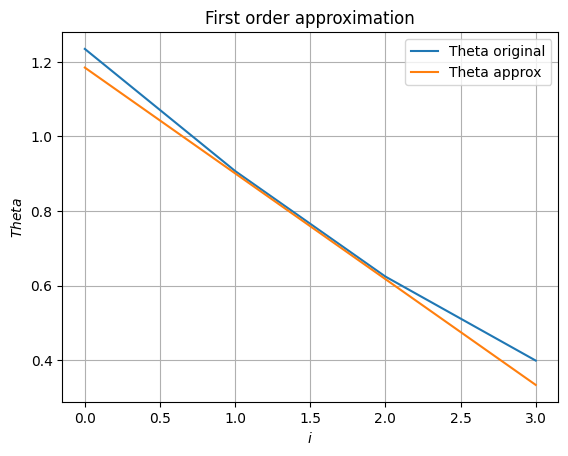

In [10]:
# Combined slope and intercept
a_k = [slope1 * 2 * z_max / ((2**n_z) - 1), slope2 * 2 * z_max / ((2**n_z) - 1)]
b_k = [-slope1 * z_max + offset1, -slope2 * z_max + offset2]

# Plotting the function
func = []
for i in [0, 1, 2, 3]:
    func.append(b_k[0] + i * a_k[0])
plt.plot(theta_p_k_z_1, label='Theta original')
plt.plot(np.array(func), label='Theta approx')
plt.title("First order approximation", size=12)
plt.grid()
plt.xlabel('$i$')
plt.ylabel('$Theta$')
plt.legend(loc="upper right")
plt.show()

### Implementation of the the quantum circuit

In [11]:
q = QuantumRegister(n_z + len(p_k), name='q')
qc = QuantumCircuit(q)
desired_vector = np.sqrt(normal_y)
qc.initialize(desired_vector, [q[0],q[1]])

### Decompose the Multiplexing "Initialize" Gate

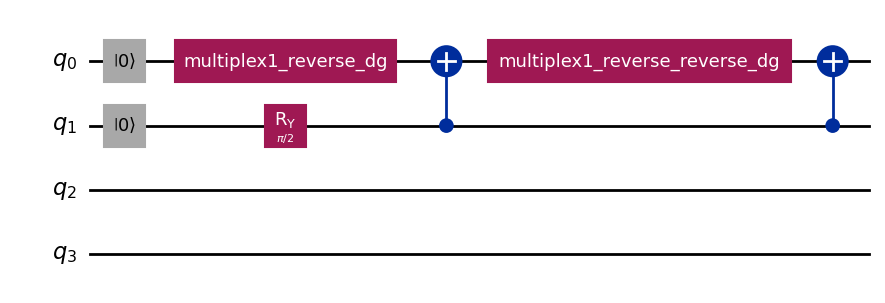

In [12]:
qc.decompose().decompose().decompose().decompose().draw('mpl')

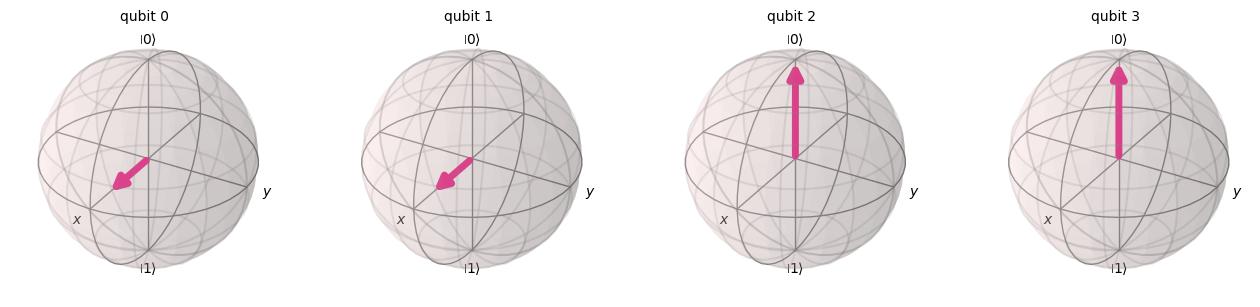

In [13]:
ackend = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
statevector = result.get_statevector()
array = np.asarray(statevector)

plot_bloch_multivector(array)

### Measurement of the results

### QASM Simulator

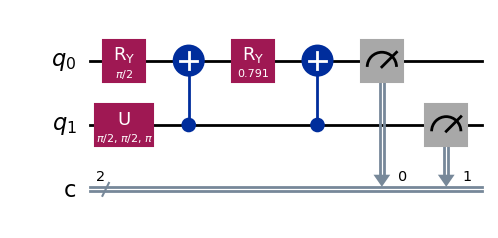

In [14]:
# Decomposed initializeation gate

q = QuantumRegister(n_z, name='q')
c = ClassicalRegister(2, 'c')
qc = QuantumCircuit(q, c)

qc.ry(pi/2, q[0])
qc.u(pi/2, pi/2, pi, q[1])
qc.cx(q[1], q[0])
qc.ry(0.7907, q[0])
qc.cx(q[1], q[0])
qc.measure(q[0], c[0])
qc.measure(q[1], c[1])

qc.draw(output='mpl')

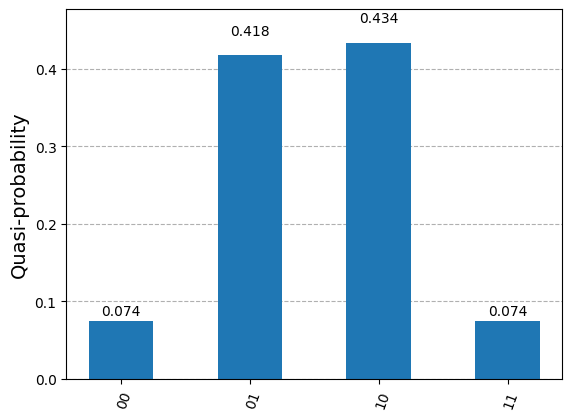

In [15]:
backend = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
counts = result.get_counts()

total_shots = sum(counts.values())
normalized_counts = {key: (value / total_shots) * 100 for key, value in counts.items()}
    
display(plot_histogram(normalized_counts))

### Statevector Simulator

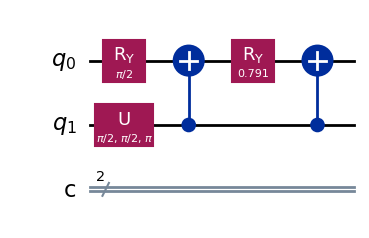

In [16]:
q = QuantumRegister(n_z, name='q')
c = ClassicalRegister(2, 'c')
qc = QuantumCircuit(q, c)

qc.ry(pi/2, q[0])
qc.u(pi/2, pi/2, pi, q[1])
qc.cx(q[1], q[0])
qc.ry(0.7907, q[0])
qc.cx(q[1], q[0])

qc.draw('mpl')

00 :  0.07228855248455421
01 :  0.42771144751544604
10 :  0.42771144751544604
11 :  0.07228855248455421


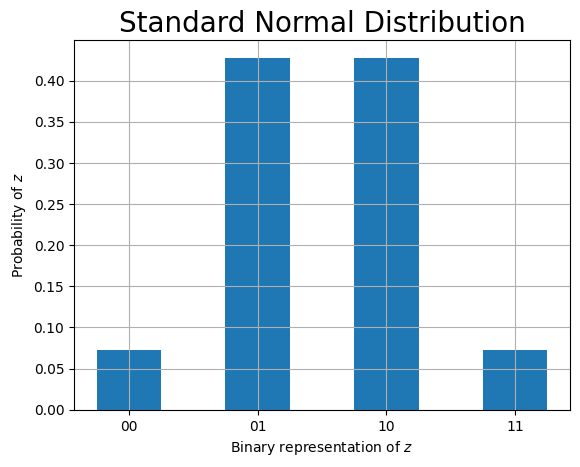

In [17]:
backend = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
statevector = result.get_statevector()
array = np.asarray(statevector)

values = []
probabilities = []
for i, a in enumerate(array):
    b = ('{0:0%sb}' % n_z).format(i)
    prob = np.abs(a)**2
    print(b, ": ", prob)
    values += [b]
    probabilities += [prob]

plt.bar(values, probabilities, width=0.5)
plt.grid()
plt.title("Standard Normal Distribution", size=20)
plt.xlabel('Binary representation of $z$')
plt.ylabel('Probability of $z$')
plt.show()

### Real quantum device

In [18]:
#from qiskit import IBMQ

# Enable Account
#token = 'Need to request token from IBM'
#IBMQ.save_account(token)
#IBMQ.enable_account(token)

# Choose provider (Quantum System)
#provider = IBMQ.get_provider(hub='ibm-q')
#backend_monitor(provider.backends.ibmq_vigo)

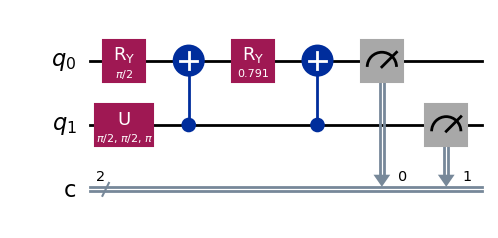

In [19]:
# Decomposed initializeation gate

q = QuantumRegister(n_z, name='q')
c = ClassicalRegister(2, 'c')
qc = QuantumCircuit(q, c)

qc.ry(pi/2, q[0])
qc.u(pi/2, pi/2, pi, q[1])
qc.cx(q[1], q[0])
qc.ry(0.7907, q[0])
qc.cx(q[1], q[0])
qc.measure(q[0], c[0])
qc.measure(q[1], c[1])

qc.draw('mpl')

In [20]:
#backend = provider.get_backend('ibmq_vigo')
#shots = 4096
#results = execute(qc, backend=backend, shots=shots).result()
#answer = results.get_counts()
#plot_histogram(answer)

### Full circuit

Implementation of the wave function $$ |\Psi\rangle = \sum_{i=0}^{2^{n_z}-1} \sqrt{p_z^i} |z_i \rangle \bigotimes_{k=1}^K 
\left( \sqrt{1 - p_k(z_i)}|0\rangle + \sqrt{p_k(z_i)}|1\rangle\right)$$

The standard normal distribution (left-hand-side of the equation) is implemented by multiplexing. When the wave function is measured it will result in $|z_i \rangle$ with a probability of $|\sqrt{p_z^i}|^2$

$$\sum_{i=0}^{2^{n_z}-1} \sqrt{p_z^i} |z_i \rangle$$

The default of each obligor is represented by one qubit each as already described above

$$\bigotimes_{k=1}^K 
\left( \sqrt{1 - p_k(z_i)}|0\rangle + \sqrt{p_k(z_i)}|1\rangle\right)$$

The default of each obligor $X_k$ dependent on the realization of $Z$ is implemented by Y-Rotations with rotation angle $\theta_p^k$ 

$$ U = \bigotimes_{k=1}^K R_Y\left(\theta_p^k\right)$$

Since the rotation angles are additive the below construction rotates qubit k by an angle $a_k z + b_k$ [Egger2019]

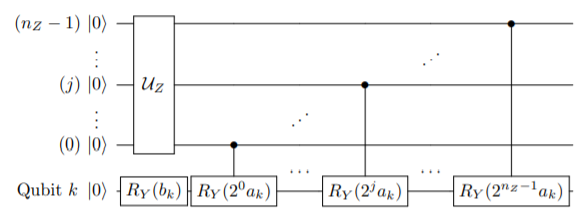
[Egger2019]

Example: In a setup with 2 qubits to represent $Z$, $z$ can take the following values $|00\rangle$, $|01\rangle$, $|10\rangle$ or $|11\rangle$ or $|0\rangle$, $|1\rangle$, $|2\rangle$ or $|3\rangle$ for $i \in \{0,...,2^{n_z-1}\}$

If the realizations of z is $|10\rangle$ (binary representation) or $|2\rangle$, which means that qubit $(0)$ becomes 0 and qubit $(1)$ becomes 1, this would trigger the following gates: $R_Y(b_k)$, $R_Y(2^1 a_k)$ and therefore rotates Qubit k by an angle of $b_k + 2 a_k$. Where the $2$ stands for $z=2$. And results in a rotation angle $\theta(z=2)$.

Higher order approximations of $\theta_p^k$ can be implemented using multi-controlled rotations. Furthermore, by using quantum arithmetic one could also compute $\theta_p^k(Y)$ directly [Egger2019].


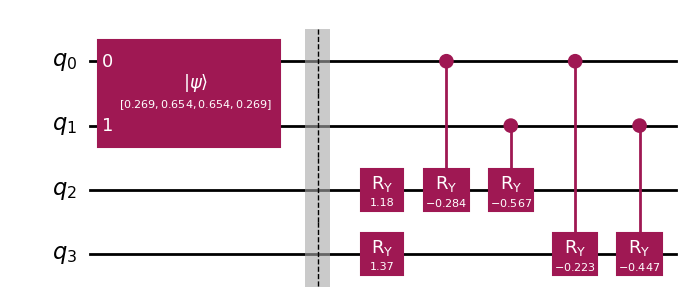

In [21]:
q = QuantumRegister(n_z + len(p_k), name='q')
qc = QuantumCircuit(q)

desired_vector = np.sqrt(normal_y)
qc.initialize(desired_vector, [q[0],q[1]])

qc.barrier()

for i in np.arange(0,len(p_k)):
    qc.ry(b_k[i], q[int(2+i)])
    qc.cry(2**0 * a_k[i], q[0], q[int(2+i)])
    qc.cry(2**1 * a_k[i], q[1], q[int(2+i)])

qc.draw('mpl')

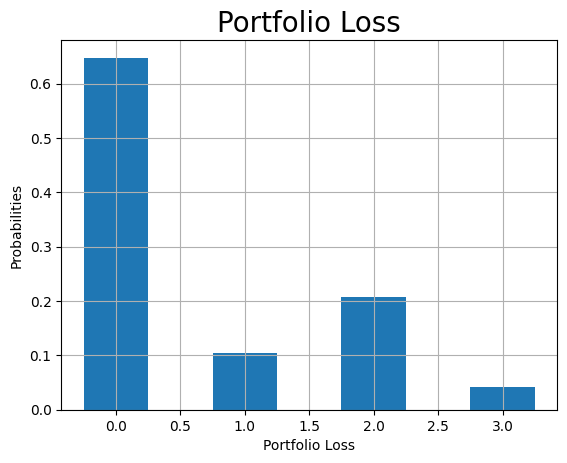

Expected Loss E[L]:                0.6409


In [22]:
backend = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
statevector = result.get_statevector()
array = np.asarray(statevector)
    
K = len(p_k)
p_z = np.zeros(2**n_z)
p_default = np.zeros(K)
values = []
probabilities = []
for i, a in enumerate(array):
    # get binary representation
    b = ('{0:0%sb}' % num_qubits).format(i)
    prob = np.abs(a)**2

    loss = 0
    for k in range(K):
        if b[K - k - 1] == '1':
            p_default[k] += prob
            loss += lgd[k]
            
    values += [loss]
    probabilities += [prob]

values = np.array(values)
probabilities = np.array(probabilities)

expected_loss = np.dot(values, probabilities)

losses = np.sort(np.unique(values))
pdf = np.zeros(len(losses))
for i, v in enumerate(losses):
    pdf[i] += sum(probabilities[values == v])
cdf = np.cumsum(pdf)

plt.bar(losses, pdf, width=0.5)
plt.grid()
plt.title("Portfolio Loss", size=20)
plt.xlabel('Portfolio Loss')
plt.ylabel('Probabilities')
plt.show()

print('Expected Loss E[L]:                %.4f' % expected_loss)

### Implementation of Weighted Adder circuit


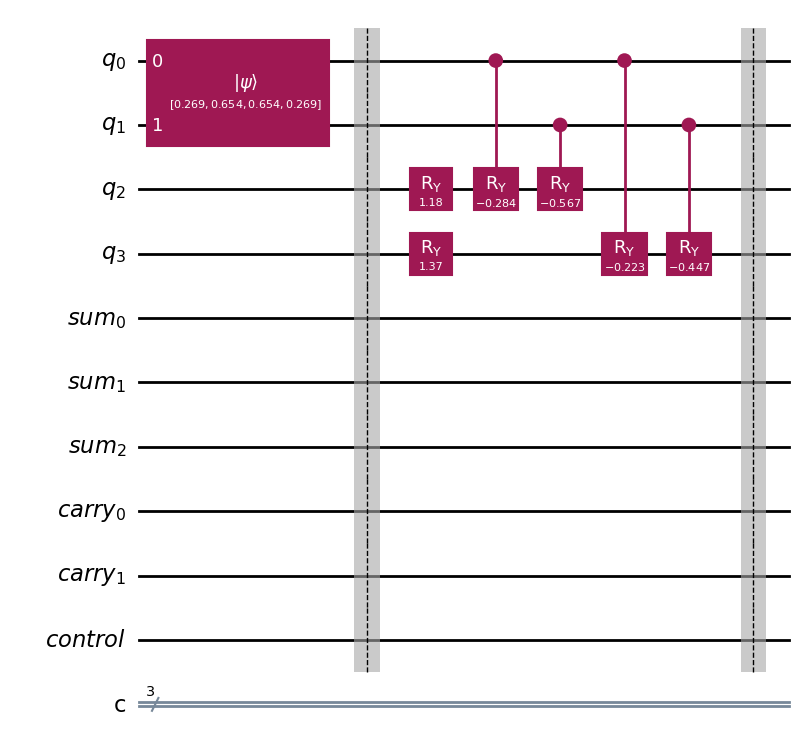

In [23]:
num_state_qubits = 2
num_sum_qubits = 3
num_carry_qubits = num_sum_qubits - 1
num_control_qubits = int(num_sum_qubits > 2)
num_result_qubits = num_state_qubits + num_sum_qubits

qr_sum = QuantumRegister(num_sum_qubits, name='sum')
qr_carry = QuantumRegister(num_carry_qubits, name='carry')
qr_control = QuantumRegister(num_control_qubits, name='control')
c = ClassicalRegister(3, 'c')
qc = QuantumCircuit(q, qr_sum, qr_carry, qr_control, c)

desired_vector = np.sqrt(normal_y)
qc.initialize(desired_vector, [q[0],q[1]])

qc.barrier()

for i in np.arange(0,len(p_k)):
    qc.ry(b_k[i], q[int(2+i)])
    qc.cry(2**0 * a_k[i], q[0], q[int(2+i)])
    qc.cry(2**1 * a_k[i], q[1], q[int(2+i)])

qc.barrier()

qc.draw('mpl')

In [24]:
weights = lgd
qr_state = [q[2],q[3]]

for i, weight in enumerate(weights):
    # get state control qubit
    q_state = qr_state[i]
    # get bit representation of current weight
    weight_binary = '{0:b}'.format(int(weight)).rjust(num_sum_qubits, '0')[::-1]
    #qiskit binary shows the least significant bit on the left and not the right

    # loop over bits of current weight and add them to sum and carry registers
    for j, bit in enumerate(weight_binary):  # from left to right, e.g. 3 = '01', output 0 and 1
        #print(bit) note weight in binary is read from left to right, e.g. 2 = '01' not '10'
        if bit == '1':   #if bit is 0 then nothing to add
            if num_sum_qubits == 1:     # only 0 and 1 are possible sums
               qc.cx(q_state, qr_sum[j])
            elif j == 0:                # first (last significant) bit is evaluated
                # compute (q_sum[0] + 1) into (q_sum[0], q_carry[0])
                # - controlled by q_state[i]
                qc.ccx(q_state, qr_sum[j], qr_carry[j])
                qc.cx(q_state, qr_sum[j])
            elif j == num_sum_qubits - 1:  # last (last significant) bit is evaluated
                # compute (q_sum[j] + q_carry[j-1] + 1) into (q_sum[j])
                # - controlled by q_state[i] / last qubit,
                # no carry needed by construction
                qc.cx(q_state, qr_sum[j])
                qc.ccx(q_state, qr_carry[j - 1], qr_sum[j]) 
            else:       # anything in between
                # compute (q_sum[j] + q_carry[j-1] + 1) into (q_sum[j], q_carry[j])
                # - controlled by q_state[i]
                # Switch 1 between sum and carry qubit
                # Next 6 commands switch qr_carry_i only if qr_sum_i and qr_carry_j-1 are different
                # and through witch not 1
                qc.x(qr_sum[j]) #switch
                qc.x(qr_carry[j - 1]) #switch back
                
                ##########################
                controls = [q_state, qr_sum[j], qr_carry[j - 1]]
                target = qr_carry[j]
                
                mcx = MCXGrayCode(num_ctrl_qubits=len(controls))
                qc.append(mcx, controls + [target])
                ##########################
                
                qc.cx(q_state, qr_carry[j])
                qc.x(qr_sum[j]) # switch back
                qc.x(qr_carry[j - 1]) # switch back
                
                qc.cx(q_state, qr_sum[j])
                qc.ccx(q_state, qr_carry[j - 1], qr_sum[j])
        else:   # if bit == '0'
            if num_sum_qubits == 1:  # bit is 0 and there is only one bit
                pass  # nothing to do, since nothing to add
            elif j == 0:
                pass  # nothing to do, since nothing to add   # bit is 0 and first bit is evaluated
            elif j == num_sum_qubits-1: # bit is 0 and last bit is evaluated
                # compute (q_sum[j] + q_carry[j-1]) into (q_sum[j])
                # - controlled by q_state[i] / last qubit,
                # no carry needed by construction
                qc.ccx(q_state, qr_carry[j - 1], qr_sum[j])
            else:       # bit is 0 and anything in between is evaluated
                # compute (q_sum[j] + q_carry[j-1]) into (q_sum[j], q_carry[j])
                # - controlled by q_state[i]
                
                ##########################
                controls = [q_state, qr_sum[j], qr_carry[j - 1]]
                target = qr_carry[j]
                
                mcx = MCXGrayCode(num_ctrl_qubits=len(controls))
                qc.append(mcx, controls + [target])
                ##########################
                
                qc.ccx(q_state, qr_carry[j - 1], qr_sum[j])
                
    # uncompute carry qubits
    for j in reversed(range(len(weight_binary))):
        bit = weight_binary[j]
        if bit == '1':
            if num_sum_qubits == 1:
                pass
            elif j == 0:
                qc.x(qr_sum[j])
                qc.ccx(q_state, qr_sum[j], qr_carry[j])
                qc.x(qr_sum[j])
            elif j == num_sum_qubits - 1:
                pass
            else:
                qc.x(qr_carry[j - 1])

                ##########################
                controls = [q_state, qr_sum[j], qr_carry[j - 1]]
                target = qr_carry[j]
                
                mcx = MCXGrayCode(num_ctrl_qubits=len(controls))
                qc.append(mcx, controls + [target])
                ##########################
                
                qc.cx(q_state, qr_carry[j])
                qc.x(qr_carry[j - 1])
        else:
            if num_sum_qubits == 1:
                pass
            elif j == 0:
                pass
            elif j == num_sum_qubits - 1:
                pass
            else:
                # compute (q_sum[j] + q_carry[j-1]) into (q_sum[j], q_carry[j])
                # - controlled by q_state[i]
                qc.x(qr_sum[j])
                
                ##########################
                controls = [q_state, qr_sum[j], qr_carry[j - 1]]
                target = qr_carry[j]
                
                mcx = MCXGrayCode(num_ctrl_qubits=len(controls))
                qc.append(mcx, controls + [target])
                ##########################
                
                qc.x(qr_sum[j])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=10, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 2), Qubit(QuantumRegister(4, 'q'), 3), Qubit(QuantumRegister(3, 'sum'), 0), Qubit(QuantumRegister(3, 'sum'), 1), Qubit(QuantumRegister(3, 'sum'), 2), Qubit(QuantumRegister(2, 'carry'), 0), Qubit(QuantumRegister(2, 'carry'), 1), Qubit(QuantumRegister(1, 'control'), 0)), clbits=())

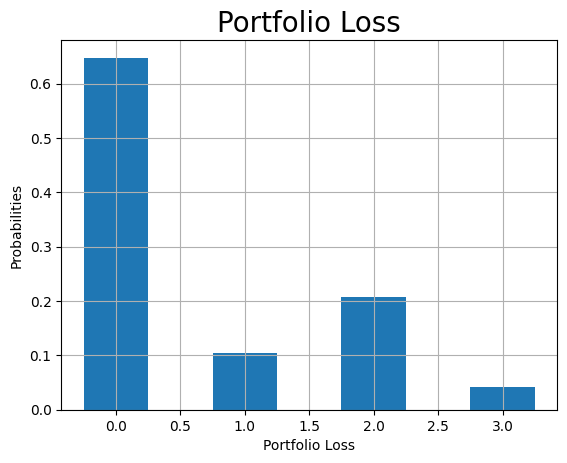

In [25]:
backend = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
statevector = result.get_statevector()
array = np.asarray(statevector)

values = []
probabilities = []
test = []
for i, a in enumerate(array):
    b = ('{0:0%sb}' % 10).format(i)
    # Qiskit reads from bottom qubit to top qubit
    values.append(int(b[3:3+3],2))
    test.append(a)
    prob = np.abs(a)**2
    probabilities.append(prob)

values = np.array(values)
probabilities = np.array(probabilities)
    
output = []
for i in np.arange(0,3.5,0.5):
    indizes = np.where(values==i)[0]
    output.append(probabilities[indizes].sum())
    
plt.bar(np.arange(0,3.5,0.5), output, width=0.5)
plt.grid()
plt.title("Portfolio Loss", size=20)
plt.xlabel('Portfolio Loss')
plt.ylabel('Probabilities')
plt.show()  

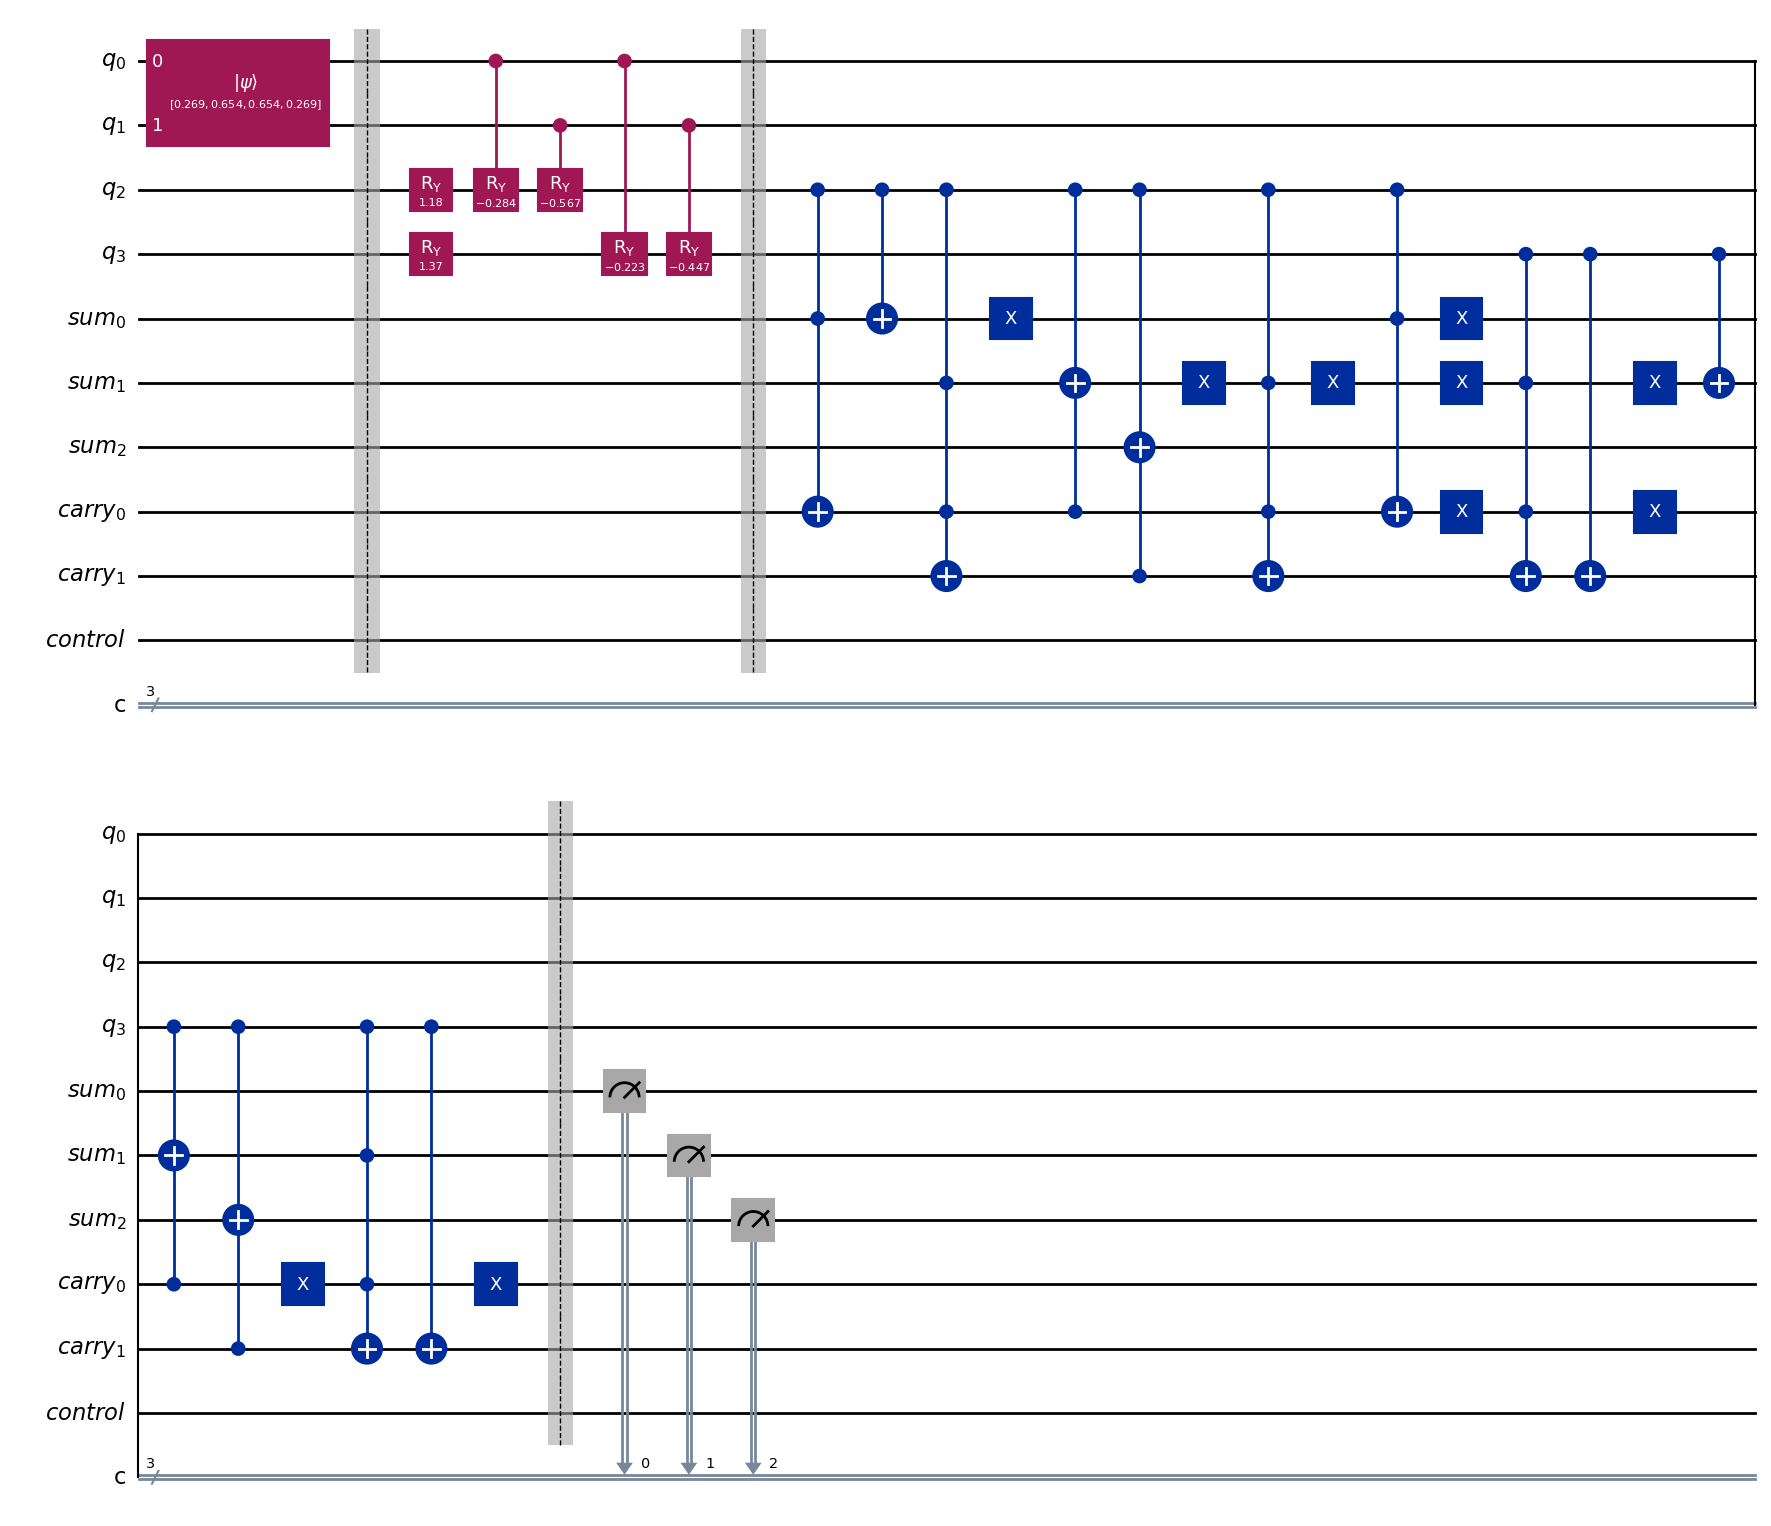

In [26]:
""" Measurement """
for n in range(3):
    qc.measure(qr_sum[n], c[n])
    
qc.draw('mpl')

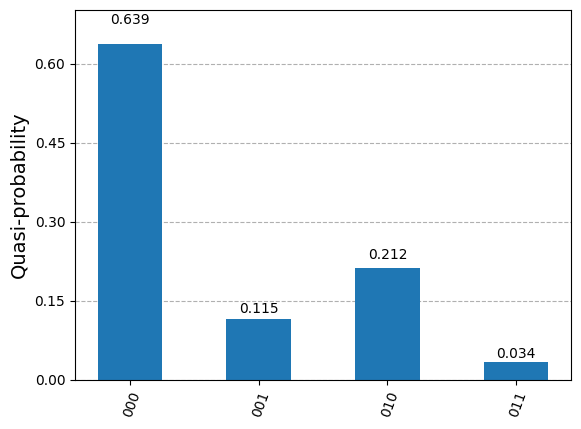

In [27]:
backend = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit)
result = job.result()
counts = result.get_counts()

total_shots = sum(counts.values())
normalized_counts = {key: (value / total_shots) * 100 for key, value in counts.items()}
    
display(plot_histogram(normalized_counts))

### Including comparator circuit

In [28]:
qr_state = QuantumRegister(4, name='state')
qc = QuantumCircuit(qr_state, name='u')

# decomposed initialization 
qc.ry(pi/2, qr_state[0])
qc.u(pi/2, pi/2, pi/2, qr_state[1]) 
qc.cx(qr_state[1], qr_state[0])
qc.ry(0.7907, qr_state[0])
qc.cx(qr_state[1], qr_state[0])

for i in np.arange(0,len(p_k)):
    qc.ry(b_k[i], qr_state[int(2+i)])
    qc.cry(2**0 * a_k[i], qr_state[0], qr_state[int(2+i)])
    qc.cry(2**1 * a_k[i], qr_state[1], qr_state[int(2+i)])

u = circuit_to_gate(qc)

In [29]:
u_inverse = u.inverse()

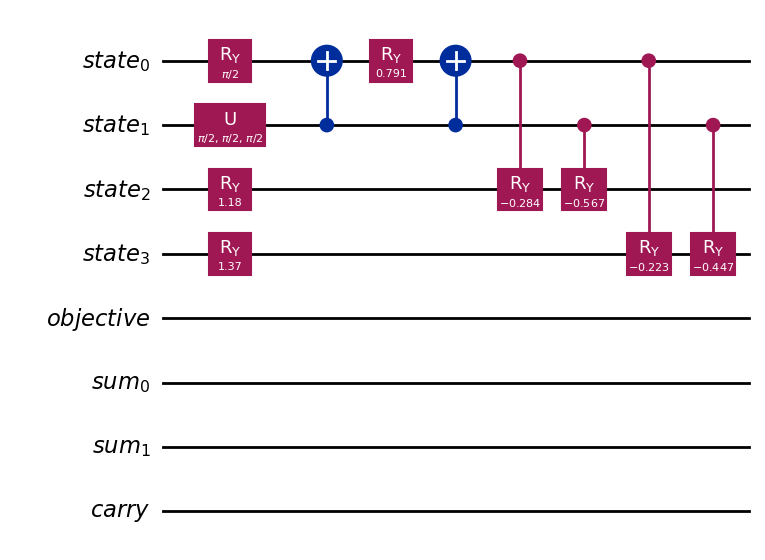

In [30]:
num_state_qubits = 2
num_sum_qubits = 2
num_carry_qubits = num_sum_qubits - 1
num_qpe_qubits = 5

qr_obj = QuantumRegister(1, 'objective')
qr_compare = QuantumRegister(1, 'compare')

qr_state = QuantumRegister(n_z + len(p_k), name='state')
qr_sum = QuantumRegister(num_sum_qubits, name='sum')
qr_carry = QuantumRegister(num_carry_qubits, name='carry')
qr_qpe = QuantumRegister(num_qpe_qubits, name='qpe')

state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name='A')

# Append state preparation
state_preparation.append(u, qr_state)

state_preparation.decompose().draw('mpl')

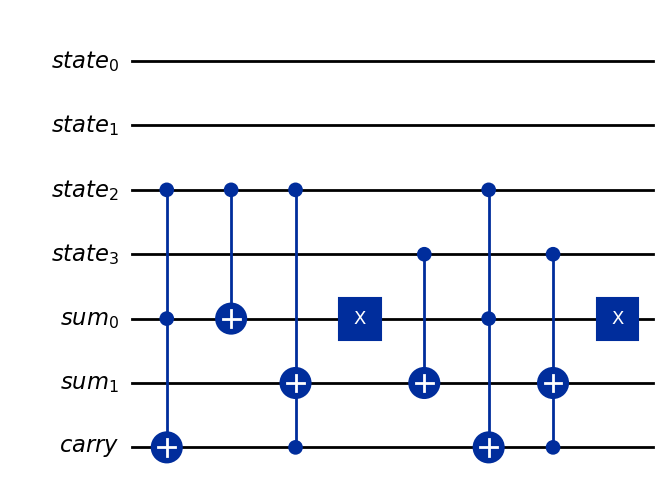

In [31]:
agg = WeightedAdder(n_z + K, [0]*n_z + lgd)
agg.decompose().draw('mpl')

In [32]:
state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])   # append the agg-gate to the mentioned qubits

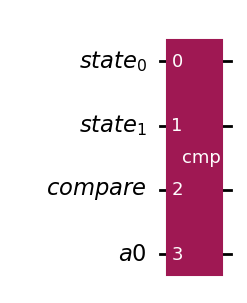

In [33]:
x_eval = 2
comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
comparator.draw('mpl')

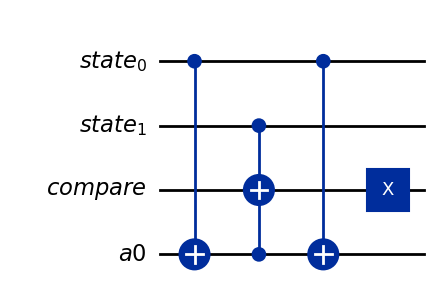

In [34]:
comparator.decompose().draw('mpl')

In [35]:
state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])

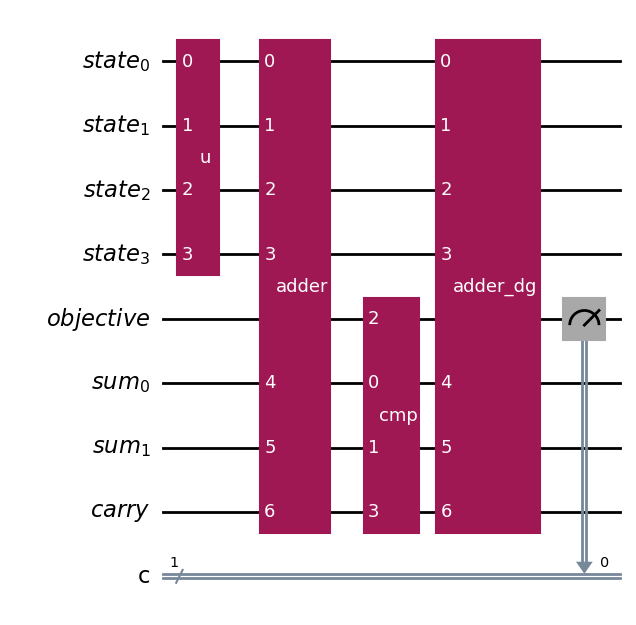

In [36]:
# uncompute aggregation
state_preparation.append(agg.inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])
state_preparation.draw('mpl')

c = ClassicalRegister(1, name='c')
state_preparation.add_register(c)

state_preparation.measure(qr_obj, c)

state_preparation.draw('mpl')

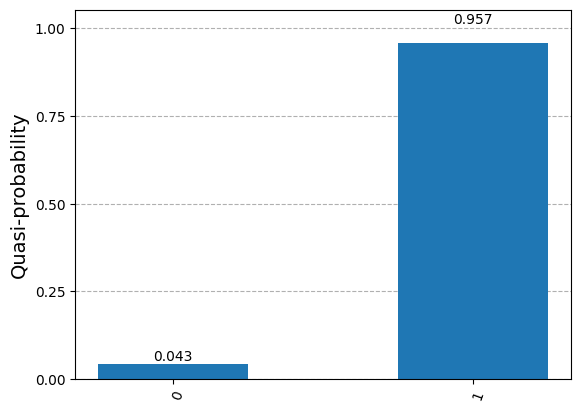

In [37]:
backend = Aer.get_backend('qasm_simulator', shots=2**12)
compiled_circuit = transpile(state_preparation, backend)
job = backend.run(compiled_circuit)
result = job.result()
counts = result.get_counts()

total_shots = sum(counts.values())
normalized_counts = {key: (value / total_shots) * 100 for key, value in counts.items()}
display(plot_histogram(normalized_counts))

## Implementation of QAE

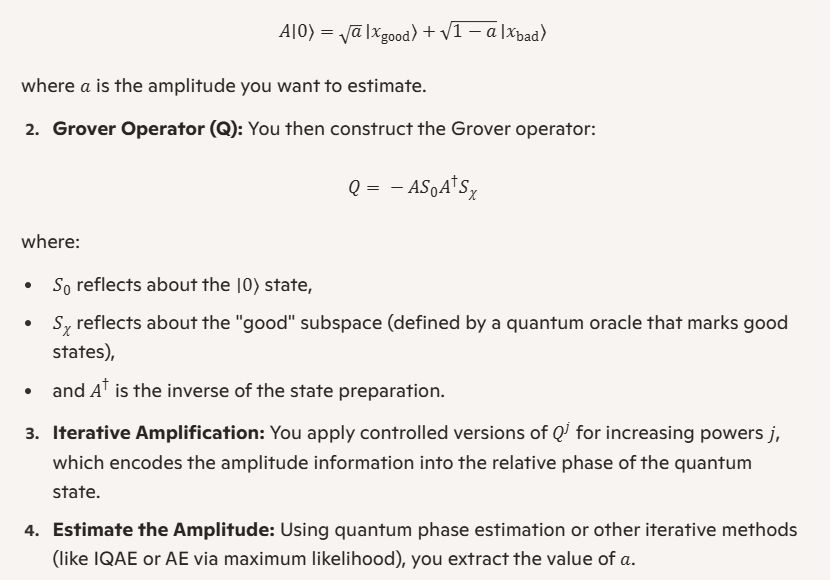

### Maximum Likelihoold Amplitude Estimation

Estimated amplitude (MLE): 0.5029


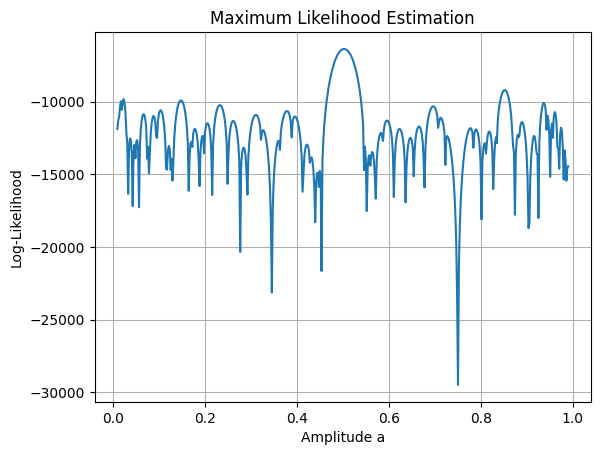

In [38]:
# Prepare A
p_k = [0.15, 0.25]
rhos = [0.1, 0.05]
lgd = [1, 2]
n_z = 2 # number of qubits representing the Standard Normal Distribution
z_max = 2
z_values = np.linspace(-z_max, z_max, 2**n_z)
num_qubits = 4 # Total number of qubits: 2 for the distribution and 2 for the obligors in the portfolio
K = len(p_k)

num_state_qubits = 2
num_sum_qubits = 2
num_carry_qubits = num_sum_qubits - 1
num_obj_qubits = 1
qr_compare = QuantumRegister(1, 'compare')

qr_state = QuantumRegister(n_z + len(p_k), name='state')
qr_sum = QuantumRegister(num_sum_qubits, name='sum')
qr_carry = QuantumRegister(num_carry_qubits, name='carry')

x_eval = 1

state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name='A')

state_preparation.append(u, qr_state)
agg = WeightedAdder(n_z + K, [0]*n_z + lgd)
state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])
comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])
state_preparation.append(agg.inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])
state_preparation.append(u.inverse(), qr_state)

A = state_preparation
A_inv = A.inverse()

# Build Grover operator manually: G = A Z A†
grover_step = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry)
grover_step.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
grover_step.z(qr_obj[0])  # Oracle phase flip
grover_step.append(A_inv, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

backend = Aer.get_backend('qasm_simulator')

k_values = [0, 1, 2, 3, 4, 5, 6, 7, 8]
shots = 1024

measurements = []
for k in k_values:
    # Create full circuit with measurements
    qc = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, ClassicalRegister(1, "meas"))
    qc.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
    
    for _ in range(k):
        qc.append(grover_step, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
    
    qc.measure(qr_obj[0], 0)
    
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=shots).result()
    counts = result.get_counts()
    n_1 = counts.get('1', 0)
    measurements.append((k, n_1))

# Likelihood function: for each a, compute log-likelihood over all k
def log_likelihood(a):
    if a <= 0.0 or a >= 1.0:
        return -np.inf  # avoid invalid domain
    theta_est = np.arcsin(np.sqrt(a))
    logL = 0
    for k, n_1 in measurements:
        p = np.sin((2 * k + 1) * theta_est) ** 2
        n_0 = shots - n_1
        # Binomial likelihood (up to additive const)
        logL += n_1 * np.log(p) + n_0 * np.log(1 - p)
    return logL

# Grid search for MLE
a_values = np.linspace(0.01, 0.99, 500)
logLs = [log_likelihood(a) for a in a_values]
a_mle = a_values[np.argmax(logLs)]

print(f"Estimated amplitude (MLE): {a_mle:.4f}")

# Optional: visualize
plt.plot(a_values, logLs)
plt.xlabel("Amplitude a")
plt.ylabel("Log-Likelihood")
plt.title("Maximum Likelihood Estimation")
plt.grid(True)
plt.show()

### Qiskit setup of Maximum Likelihood Amplitude Estimation

In [40]:
from qiskit_algorithms import MaximumLikelihoodAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import ZGate
from qiskit import QuantumCircuit
from numpy import arcsin, sqrt
from qiskit.primitives import Sampler

# Prepare A
p_k = [0.15, 0.25]
rhos = [0.1, 0.05]
lgd = [1, 2]
n_z = 2 # number of qubits representing the Standard Normal Distribution
z_max = 2
z_values = np.linspace(-z_max, z_max, 2**n_z)
num_qubits = 4 # Total number of qubits: 2 for the distribution and 2 for the obligors in the portfolio
K = len(p_k)

x_eval = 1

num_state_qubits = 2
num_sum_qubits = 2
num_carry_qubits = num_sum_qubits - 1
num_obj_qubits = 1
qr_compare = QuantumRegister(1, 'compare')

qr_state = QuantumRegister(n_z + len(p_k), name='state')
qr_sum = QuantumRegister(num_sum_qubits, name='sum')
qr_carry = QuantumRegister(num_carry_qubits, name='carry')

state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name='A')

state_preparation.append(u, qr_state)
agg = WeightedAdder(n_z + K, [0]*n_z + lgd)
state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])
comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])
state_preparation.append(agg.inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])
state_preparation.append(u.inverse(), qr_state)

A = state_preparation
A_inv = A.inverse()

# Build Grover operator manually: G = A Z A†
grover_step = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry)
grover_step.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
grover_step.z(qr_obj[0])  # Oracle phase flip
grover_step.append(A_inv, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

sampler = Sampler()

# Define the state preparation circuit
qc = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, ClassicalRegister(1, "meas"))
qc.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

grover = grover_step

# Define the estimation problem
problem = EstimationProblem(
    state_preparation=qc,
    grover_operator=grover,
    objective_qubits=[4]
)

# Define the estimator
mlae = MaximumLikelihoodAmplitudeEstimation(
    evaluation_schedule=[0, 1, 2, 3, 4, 5],
    sampler=sampler
)

iae = IterativeAmplitudeEstimation(
    epsilon_target=0.01,  # desired precision
    alpha=0.05,           # confidence level
    sampler=Sampler()     # optional: customize backend or seed
)

# Step 5: Run the estimation
result = iae.estimate(problem)
print("Estimated amplitude:", result.estimation)

# Run the estimation
result = mlae.estimate(problem)
print("Estimated amplitude:", result.estimation)

Estimated amplitude: 0.75211527721119
Estimated amplitude: 0.4946994367819426


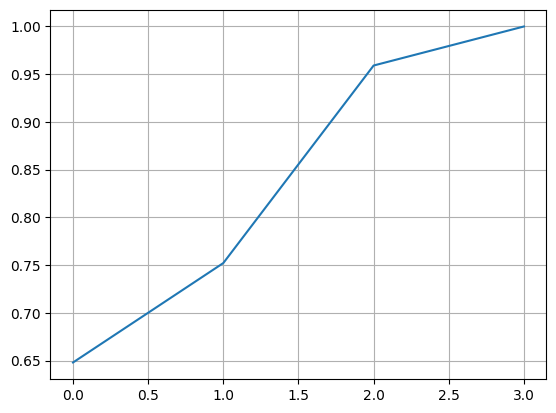

In [41]:
x = np.array([0, 1, 2, 3])
y = np.array([0.647928275902344, 0.75211527721119, 0.9590895982634892, 1])

plt.plot(x, y)
plt.grid()
plt.show()

### Iterative Amplitude Estimation

In [42]:
# a = sin**2(theta) or theta = arcsin(sqrt(a))
#I_0 = [theta_low, theta_high], [0, pi/2]
# m = (theta_low + theta_high) / 2
# measure result:
# more likely theta < m: I_j+1 = [theta_low, m] = [0, pi/4]
# more likely theta >= m : I_j+1 = [m, theta_high] = [pi/4, pi/2]
# after each iteration sin**2((2k+1)*theta)
# each iteration halves the search space
# once interval narrow enough, width (theta_high - theta_low) less than target error tollerance epsilon
# stop and return: a = sin**2((theta_low + theta_high) / 2), midpoint of the final interval

In [307]:
x_eval = 2
p_k = [0.15, 0.25]
rhos = [0.1, 0.05]
lgd = [1, 2]
num_qubits = 4 
K = len(p_k)

thetas_ry = 2 * arcsin(sqrt(p_k))

num_state_qubits = 2
num_sum_qubits = 2
num_carry_qubits = num_sum_qubits - 1
num_obj_qubits = 1
qr_compare = QuantumRegister(1, 'compare')

qr_state = QuantumRegister(len(p_k), name='state')
qr_sum = QuantumRegister(num_sum_qubits, name='sum')
qr_carry = QuantumRegister(num_carry_qubits, name='carry')

state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name='A')

state_preparation.ry(thetas_ry[0], qr_state[0])
state_preparation.ry(thetas_ry[1], qr_state[1])
state_preparation.barrier()
agg = WeightedAdder(K, lgd)
state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])
state_preparation.barrier()
comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])

state_preparation.decompose().decompose().draw()

┌────────────────┐ ░                                          ░      »
state_0: ┤ U3(0.7954,0,0) ├─░───■────■────■──────────────■─────────────░──────»
         └┬─────────────┬─┘ ░   │    │    │              │             ░      »
state_1: ─┤ U3(π/3,0,0) ├───░───┼────┼────┼─────────■────┼────■────────░──────»
          └─────────────┘   ░   │    │    │         │    │    │        ░      »
    obj: ───────────────────░───┼────┼────┼─────────┼────┼────┼────────░──────»
                            ░   │  ┌─┴─┐  │  ┌───┐  │    │    │  ┌───┐ ░      »
  sum_0: ───────────────────░───■──┤ X ├──┼──┤ X ├──┼────■────┼──┤ X ├─░───■──»
                            ░   │  └───┘┌─┴─┐└───┘┌─┴─┐  │  ┌─┴─┐└───┘ ░   │  »
  sum_1: ───────────────────░───┼───────┤ X ├─────┤ X ├──┼──┤ X ├──────░───┼──»
                            ░ ┌─┴─┐     └─┬─┘     └───┘┌─┴─┐└─┬─┘      ░ ┌─┴─┐»
  carry: ───────────────────░─┤ X ├───────■────────────┤ X ├──■────────░─┤ X ├»
                            ░ └───┘                    └───┘           ░ └───┘»
«                   
«state_0: ──────────
«                   
«state_1: ──────────
«         ┌───┐┌───┐
«    obj: ┤ X ├┤ X ├
«         └─┬─┘└───┘
«  sum_0: ──┼────■──
«           │    │  
«  sum_1: ──■────┼──
«           │  ┌─┴─┐
«  carry: ──■──┤ X ├
«              └───┘

In [293]:
x_evals = [0, 1, 2, 3]
k_val = list(range(20))
a_values = []

for x_eval in x_evals:
    p_k = [0.15, 0.25]
    rhos = [0.1, 0.05]
    lgd = [1, 2]
    #n_z = 2
    #z_max = 2
    #z_values = np.linspace(-z_max, z_max, 2**n_z)
    num_qubits = 4 
    K = len(p_k)

    thetas_ry = 2 * arcsin(sqrt(p_k))
    
    num_state_qubits = 2
    num_sum_qubits = 2
    num_carry_qubits = num_sum_qubits - 1
    num_obj_qubits = 1
    qr_compare = QuantumRegister(1, 'compare')
    
    #qr_state = QuantumRegister(n_z + len(p_k), name='state')
    qr_state = QuantumRegister(len(p_k), name='state')
    qr_sum = QuantumRegister(num_sum_qubits, name='sum')
    qr_carry = QuantumRegister(num_carry_qubits, name='carry')
    
    state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name='A')
    
    #state_preparation.append(u, qr_state)
    state_preparation.ry(thetas_ry[0], qr_state[0])
    state_preparation.ry(thetas_ry[1], qr_state[1])
    #agg = WeightedAdder(n_z + K, [0]*n_z + lgd)
    agg = WeightedAdder(K, lgd)
    state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])
    comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
    state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])
    state_preparation.append(agg.inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])
    state_preparation.ry(-thetas_ry[0], qr_state)
    state_preparation.ry(-thetas_ry[1], qr_state)
    #state_preparation.append(u.inverse(), qr_state)
    
    A = state_preparation
    A_inv = A.inverse()
    
    grover_step = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry)
    grover_step.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
    grover_step.z(qr_obj[0])  # Oracle phase flip
    grover_step.append(A_inv, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

    thetas = []
    theta_low_save = []
    theta_high_save = []
    m_save = []
    
    theta_low = 0
    theta_high = np.pi/2

    for k in k_val:
        qc = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, ClassicalRegister(1, "meas"))
        qc.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
        
        for _ in range(k):
            qc.append(grover_step, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
        
        qc.measure(qr_obj[0], 0)
        
        shots = 100
        compiled = transpile(qc, backend)
        result = backend.run(compiled, shots=shots).result()
        counts = result.get_counts()
        
        success = counts.get("1", 0)
        a = success / shots
        
        thetas.append(arcsin(sqrt(a)))

    for theta in thetas:
        m = (theta_low + theta_high) / 2
        if theta < m:
            theta_low = theta_low
            theta_high = m
        
        elif theta >= m:
            theta_low = m
            theta_high = theta_high
        
        theta_low_save.append(theta_low)
        theta_high_save.append(theta_high)
        m_save.append(m)

        if (theta_high - theta_low) < 0.01:
            a_values.append(np.sin((theta_low + theta_high) / 2)**2)
            break

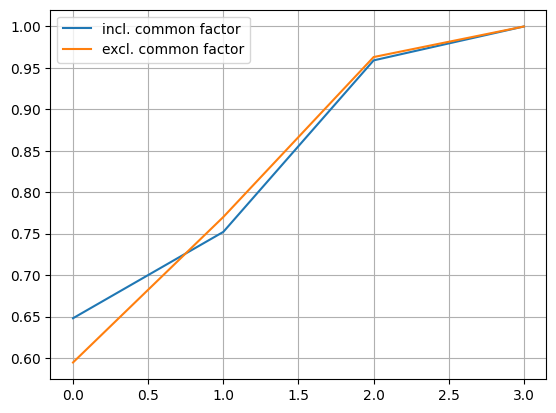

In [294]:
x = np.array([0, 1, 2, 3])
y = np.array([0.647928275902344, 0.75211527721119, 0.9590895982634892, 1])

plt.plot(x, y, label="incl. common factor")
plt.plot(x, a_values, label="excl. common factor")
plt.grid()
plt.legend()
plt.show()

In [287]:
x_evals = [0, 1, 2, 3]
k_val = list(range(20))
a_values = []

backend = Aer.get_backend('qasm_simulator')

for x_eval in x_evals:
    p_k = [0.15, 0.25]
    lgd = [1, 2]
    K = len(p_k)

    thetas_ry = 2 * np.arcsin(np.sqrt(p_k))

    num_sum_qubits = 2
    num_carry_qubits = num_sum_qubits - 1
    num_obj_qubits = 1

    qr_state = QuantumRegister(K, name='state')
    qr_sum = QuantumRegister(num_sum_qubits, name='sum')
    qr_carry = QuantumRegister(num_carry_qubits, name='carry')
    qr_obj = QuantumRegister(1, name='obj')
    cr = ClassicalRegister(1, name='meas')

    state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name='A')
    for i in range(K):
        state_preparation.ry(thetas_ry[i], qr_state[i])

    agg = WeightedAdder(K, lgd)
    state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])

    comparator = IntegerComparator(num_sum_qubits, x_eval + 1, geq=False)
    state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])

    A = state_preparation
    A_inv = A.inverse()

    grover_step = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry)
    grover_step.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])
    grover_step.z(qr_obj[0])
    grover_step.append(A_inv, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

    thetas = []
    theta_low = 0
    theta_high = np.pi / 2

    for k in k_val:
        qc = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, cr)
        qc.append(A, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

        for _ in range(k):
            qc.append(grover_step, qr_state[:] + qr_obj[:] + qr_sum[:] + qr_carry[:])

        qc.measure(qr_obj[0], cr[0])

        shots = 100
        compiled = transpile(qc, backend)
        result = backend.run(compiled, shots=shots).result()
        counts = result.get_counts()

        success = counts.get("1", 0)
        a = success / shots
        thetas.append(np.arcsin(np.sqrt(a)))

    for theta in thetas:
        m = (theta_low + theta_high) / 2
        if theta < m:
            theta_high = m
        else:
            theta_low = m

        if (theta_high - theta_low) < 0.01:
            a_values.append(np.sin((theta_low + theta_high) / 2) ** 2)
            break


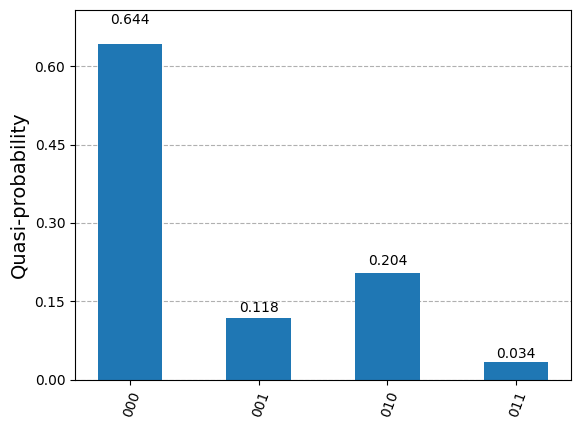

In [280]:
thetas_ry = 2 * arcsin(sqrt(p_k))

c = ClassicalRegister(3)

qr_state = QuantumRegister(len(p_k), name='state')
qr_sum = QuantumRegister(num_sum_qubits, name='sum')
qr_carry = QuantumRegister(num_carry_qubits, name='carry')
qc = QuantumCircuit(qr_state, qr_sum, qr_carry, c)

qc.ry(thetas_ry[0], 0)
qc.ry(thetas_ry[1], 1)

qc.barrier()

agg = WeightedAdder(K, lgd)
qc.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])

qc.barrier()

qc.measure([qr_sum[0], qr_sum[1], qr_carry[0]], c)
        
backend = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

total_shots = sum(counts.values())
normalized_counts = {key: (value / total_shots) * 100 for key, value in counts.items()}
    
display(plot_histogram(normalized_counts))

In [235]:
qc.decompose().decompose().draw()

┌────────────────┐ ░                                          ░       »
state_0: ┤ U3(0.7954,0,0) ├─░───■────■────■──────────────■─────────────░───────»
         └┬─────────────┬─┘ ░   │    │    │              │             ░       »
state_1: ─┤ U3(π/3,0,0) ├───░───┼────┼────┼─────────■────┼────■────────░───────»
          └─────────────┘   ░   │  ┌─┴─┐  │  ┌───┐  │    │    │  ┌───┐ ░ ┌─┐   »
  sum_0: ───────────────────░───■──┤ X ├──┼──┤ X ├──┼────■────┼──┤ X ├─░─┤M├───»
                            ░   │  └───┘┌─┴─┐└───┘┌─┴─┐  │  ┌─┴─┐└───┘ ░ └╥┘┌─┐»
  sum_1: ───────────────────░───┼───────┤ X ├─────┤ X ├──┼──┤ X ├──────░──╫─┤M├»
                            ░ ┌─┴─┐     └─┬─┘     └───┘┌─┴─┐└─┬─┘      ░  ║ └╥┘»
  carry: ───────────────────░─┤ X ├───────■────────────┤ X ├──■────────░──╫──╫─»
                            ░ └───┘                    └───┘           ░  ║  ║ »
  c26: 3/═════════════════════════════════════════════════════════════════╩══╩═»
                                                                          0  1 »
«            
«state_0: ───
«            
«state_1: ───
«            
«  sum_0: ───
«            
«  sum_1: ───
«         ┌─┐
«  carry: ┤M├
«         └╥┘
«  c26: 3/═╩═
«          2

### Simple setup

In [139]:
theta = 2 * arcsin(sqrt(0.6))
k_val = list(range(5))

state_preparation = QuantumCircuit(1)
state_preparation.ry(theta, 0)
A = state_preparation
A_inv = A.inverse()

grover_step = QuantumCircuit(1)
grover_step.compose(A, inplace=True)
grover_step.z(0)
grover_step.compose(A.inverse(), inplace=True)

theta_low = 0
theta_high = np.pi/2
m_save = []

for k in k_val:
    qc = QuantumCircuit(1)
    qc.compose(A, inplace=True)
    
    for _ in range(k):
        qc.compose(grover_step, inplace=True)
    
    qc.measure_all()
    
    shots = 100
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=shots).result()
    counts = result.get_counts()
    
    success = counts.get("1", 0)
    a = success / shots
    
    thetas.append(arcsin(sqrt(a)))

for theta in thetas:
    m = (theta_low + theta_high) / 2
    if theta < m:
        theta_low = theta_low
        theta_high = m
    
    elif theta >= m:
        theta_low = m
        theta_high = theta_high

    if (theta_high - theta_low) < 0.01:
        a_values.append(np.sin((theta_low + theta_high) / 2)**2)
        break

### Minimal setup

In [ ]:
def build_iqae_circuit(A, grover_step, k, obj_qubit):
    qc = QuantumCircuit(A.num_qubits, 1)
    qc.append(A, range(A.num_qubits))
    for _ in range(k):
        qc.append(grover_step, range(A.num_qubits))
    qc.measure(obj_qubit, 0)
    return qc

def clopper_pearson(k_success, n_shots, alpha=0.05):
    lower = beta.ppf(alpha / 2, k_success, n_shots - k_success + 1) if k_success > 0 else 0.0
    upper = beta.ppf(1 - alpha / 2, k_success + 1, n_shots - k_success) if k_success < n_shots else 1.0
    return lower, upper

def run_diy_iqae(A, grover_step, obj_qubit, epsilon=0.01, alpha=0.05, shots=1000, k_max=25):
    backend = Aer.get_backend('qasm_simulator')
    k_vals = []
    theta_interval = [0, np.pi / 2]

    for k in range(k_max):
        qc = build_iqae_circuit(A, grover_step, k, obj_qubit)
        transpiled = transpile(qc, backend)
        result = backend.run(transpiled, shots=shots).result()
        counts = result.get_counts()
        success = counts.get("1", 0)
        p_hat = success / shots

        p_lower, p_upper = clopper_pearson(success, shots, alpha=alpha)
        theta_min = asin(sqrt(max(0, p_lower))) / (2 * k + 1)
        theta_max = asin(sqrt(min(1, p_upper))) / (2 * k + 1)

        theta_interval[0] = max(theta_interval[0], theta_min)
        theta_interval[1] = min(theta_interval[1], theta_max)
        k_vals.append(k)

        if theta_interval[1] - theta_interval[0] < epsilon:
            break

    theta_est = sum(theta_interval) / 2
    a_est = sin(theta_est) ** 2
    return a_est, k_vals

In [ ]:
# how to determine the best fit
#non linear regression or grid search to fit to 
#P = sin**2((2*k+1)*theta)
#solve for theta and use a=sin**2(theta) to get
# k_opt = [pi/(4*theta) -1/2]
#non linear regression or grid search

# Your measured success probabilities from k = 0 to k = N
p_data = results
k_vals = np.arange(len(p_data))

# Define the model function: P(k) = sin²((2k + 1)θ)
def grover_model(k, theta):
    return np.sin((2 * k + 1) * theta)**2

# Fit the curve to find theta
theta_guess = 0.5  # initial guess
params, _ = curve_fit(grover_model, k_vals, p_data, p0=[theta_guess])
theta_fit = params[0]

# Compute amplitude and optimal number of iterations
a_estimate = np.sin(theta_fit)**2
k_opt = int(np.floor((np.pi / (4 * theta_fit)) - 0.5))

print(f"Estimated amplitude a ≈ {a_estimate:.4f}")
print(f"Estimated optimal Grover iterations ≈ {k_opt}")

# Plotting
k_plot = np.linspace(0, len(p_data), 300)
p_fit = grover_model(k_plot, theta_fit)

plt.figure(figsize=(8, 4))
plt.plot(k_vals, p_data, 'o', label="Measured")
plt.plot(k_plot, p_fit, label="Fitted sin²((2k+1)θ)", color='orange')
plt.xlabel("Grover iteration k")
plt.ylabel("Probability of good state")
plt.title("Grover Amplitude Oscillation Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
full_circuit.decompose().draw('mpl')

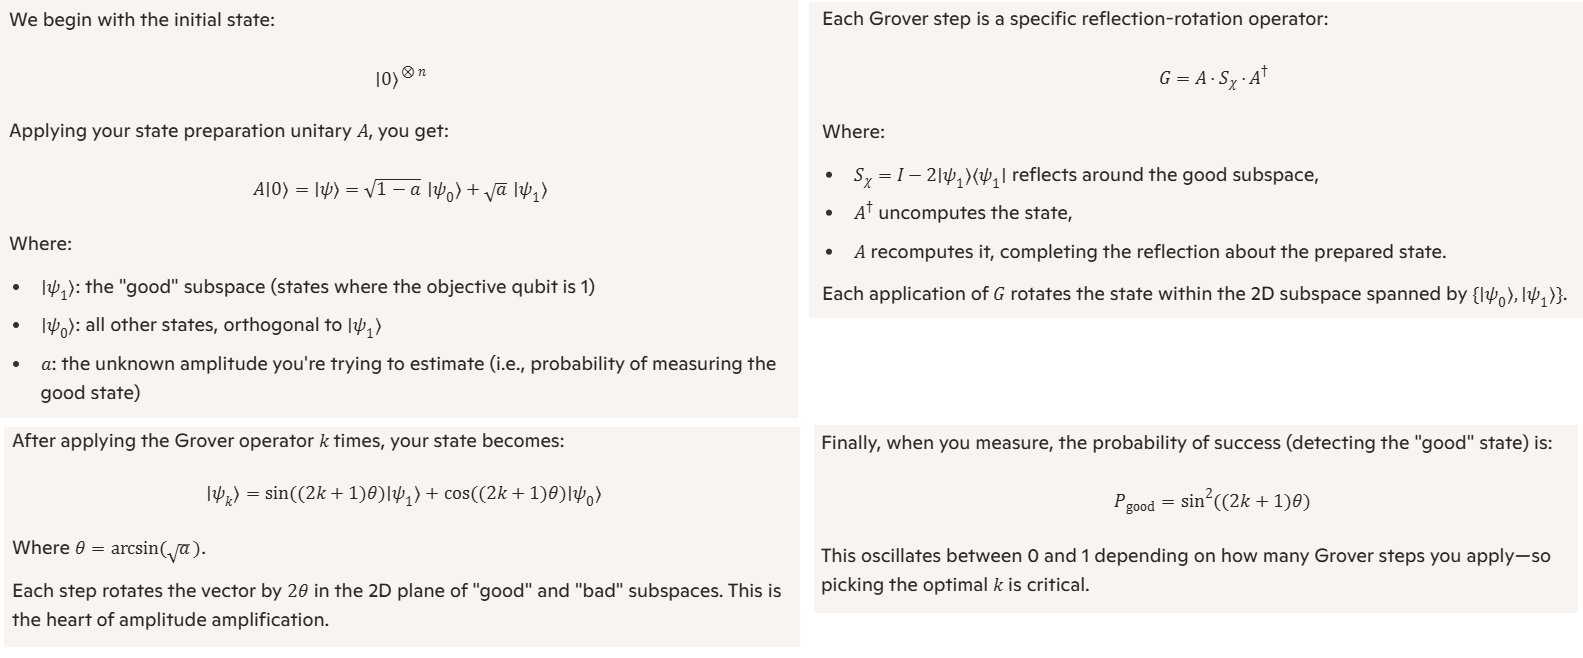

In [ ]:
# Multi-contol Toffoli gate
# https://qiskit.org/documentation/apidoc/circuit_library.html
n_z = n_z
K = K
n_S = num_sum_qubits + num_carry_qubits
n_O = num_obj_qubits = 1

#mult = mcmt(ZGate(), n_z  + n_S + n_O, 1)

# MCMTVChain(gate, num_ctrl_qubits, num_target_qubits, label=None)
mult = MCMTVChain(ZGate(), n_z + n_S + n_O, 1)
mult.draw('mpl')

In [ ]:
n_z + n_S + n_O

### Comparison of the results to the ASFR model

In [ ]:
""" Schoenbucher, binomial distribution, one-factor model"""
# This model can only model a homogeneous portfolio with the same probability of default for all obligors in the portfolio
import scipy.special
K = norm.ppf(p_k[0])
borrower = 2
rho = rhos[0]
y = np.arange(-3,3,0.01)
out = []
for n in np.arange(0, borrower+1):
    out.append(np.trapz(np.sum(scipy.special.binom(borrower, n) * (norm.cdf((K - np.sqrt(rho)*y.reshape(len(y),1)))/(np.sqrt(1-rho)))**n * \
        (1-norm.cdf((K - np.sqrt(rho)*y.reshape(len(y),1)))/(np.sqrt(1-rho)))**(borrower-n), axis=1) * norm.pdf(y), y))
plt.bar(np.arange(0, borrower+1), out)
plt.title("Portfolio Loss Distribution in the ASFR model", size=20)
plt.grid()

### Comparison of the results to the Monte-Carlo model

In [ ]:
""" Monte-Carlo Simulation """
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt  
from scipy.stats import lognorm, norm, linregress

factors = 1
borrower = 2
sims = 50000
p_k = [0.15, 0.25]
rhos = [0.1, 0.05]
lgd = [1, 2]

z = np.random.normal(0, 1, (factors, sims))
obligor_obs = np.random.normal(0, 1, (borrower, sims))

loss = 0
for i, a in enumerate(p_k):
    p_k_z = norm.cdf((norm.ppf(p_k[i]) - np.sqrt(p_k[i])*z)  / (np.sqrt(1-rhos[i])))[0]
    loss += (norm.cdf(obligor_obs[i]) < p_k_z) * 1 * lgd[i]
  
print("Expected Loss: ", loss.sum() / sims)

unique, counts = np.unique(np.array(loss), return_counts=True)
counts = counts / sims

plt.bar(unique, counts, width = 0.5)
plt.grid()
plt.title("Portfolio Loss", size=20)
plt.xlabel('Portfolio Loss')
plt.ylabel('Probabilities')
plt.show()

### Iterative Amplitude Estimation (concept)

In [110]:
theta = 2 * arcsin(sqrt(0.6))
state_prep = QuantumCircuit(1)
state_prep.ry(theta, 0)

# Define the Grover operator (reflection around the initial state)
grover_op = QuantumCircuit(1)
grover_op.z(0)  # Just a Z gate in one-qubit case

# Define the estimation problem
problem = EstimationProblem(
    state_preparation=state_prep,
    grover_operator=grover_op,
    objective_qubits=[0]
)

# Run Iterative Amplitude Estimation
sampler = Sampler()
iae = IterativeAmplitudeEstimation(
    epsilon_target=0.01,
    alpha=0.05,
    sampler=sampler
)

result = iae.estimate(problem)

# Output the result
print("Estimated amplitude squared (prob of |1⟩):", result.estimation)


Estimated amplitude squared (prob of |1⟩): 0.6000000000000001


In [ ]:
theta = 2 * arcsin(sqrt(0.6))

backend = Aer.get_backend('qasm_simulator')

k_values = [0, 1, 2, 3, 4]
shots = 100

measurements = []
for k in k_values:
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    
    for _ in range(k):
        qc.z(0)
        qc.ry(-theta, 0)
        qc.z(0)
        qc.ry(theta, 0)

    qc.measure(0, 0)
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=shots).result()
    counts = result.get_counts()
    n_1 = counts.get('1', 0)
    measurements.append((k, n_1))

# Likelihood function: for each a, compute log-likelihood over all k
def log_likelihood(a):
    if a <= 0.0 or a >= 1.0:
        return -np.inf  # avoid invalid domain
    theta_est = np.arcsin(np.sqrt(a))
    logL = 0
    for k, n_1 in measurements:
        p = np.sin((2 * k + 1) * theta_est) ** 2 # probability measuring in good_state
        n_0 = shots - n_1 # number of shots measured state 0, whereas n_1 is number of shots measured 1
        # Binomial likelihood (up to additive const)
        # random event with two possible outcomes (success or failure)
        # P(X=1) = p and P(X=0) = (1-p)
        # if we repeat the number of shots the total number of successes will converge to a binomial distribution
        logL += n_1 * np.log(p) + n_0 * np.log(1 - p) # prob of n_1 successes in N trials
        # P(n_1 in N trials) = (N n_1) * p**n1 (1-p)**n0
        # logL(p) = log(...) = log(N n_1) + n_1 log(p) + n_0 log(1-p)
        # binomial coefficient log(N n_1) is constant, does not affect where max occurs
        # logL(p) proportional to n_1 log(p) + n_0 log(1-p)
        # logL(a) = n_1(k) log(p_k(a)) + n_0(k) log(1-p_k(a)) for every experiment k
        # logL total is the sum over these statistically individually independent measurments
    return logL

# Grid search for MLE
a_values = np.linspace(0.01, 0.99, 500)
logLs = [log_likelihood(a) for a in a_values]
a_mle = a_values[np.argmax(logLs)]

print(f"Estimated amplitude (MLE): {a_mle:.4f}")

plt.plot(a_values, logLs)
plt.xlabel("Amplitude a")
plt.ylabel("Log-Likelihood")
plt.title("Maximum Likelihood Estimation")
plt.grid(True)
plt.show()

In [ ]:
measurements

In [ ]:
# a = probability between [0, 1] maps to theta between [0, pi/2]
np.pi/2, np.arcsin(np.sqrt(1))

In [ ]:
plt.plot(np.linspace(0.01, 0.99, 500), np.arcsin(np.sqrt(np.linspace(0.01, 0.99, 500))))
plt.grid()
plt.plot()

In [ ]:
p_true = 0.6
shots = 1000
trials = 10000

# Simulate 10,000 rounds of quantum circuits with 1000 shots each
successes = np.random.binomial(n=shots, p=p_true, size=trials)

# Plot the histogram of observed '1' counts
plt.hist(successes, bins=50, density=True, alpha=0.6, color='steelblue', label='Simulated data')

# Overlay the theoretical binomial distribution
x = np.arange(min(successes), max(successes))
binom_probs = binom.pmf(x, n=shots, p=p_true)
plt.plot(x, binom_probs, 'r-', lw=2, label='Binomial PMF')

plt.xlabel("Number of '1's in 1000 shots")
plt.ylabel("Probability density")
plt.title("Bernoulli Trials → Binomial Distribution")
plt.legend()
plt.grid(True)
plt.show()

### Probabilities only

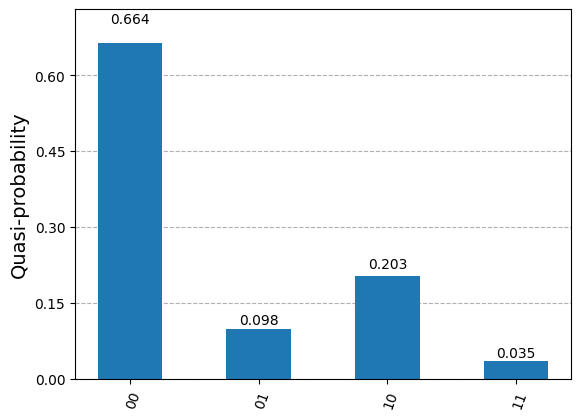

In [313]:
thetas_ry = 2 * arcsin(sqrt(p_k))

c = ClassicalRegister(2)

qr_state = QuantumRegister(len(p_k), name='state')
qc = QuantumCircuit(qr_state, c)

qc.ry(thetas_ry[0], 0)
qc.ry(thetas_ry[1], 1)

qc.measure(qr_state, c)
        
backend = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

total_shots = sum(counts.values())
normalized_counts = {key: (value / total_shots) * 100 for key, value in counts.items()}
    
display(plot_histogram(normalized_counts))